# HOMEWORK 3

For this homework you are going to implement the **unsharp masking** filter (USM). It is a technique to improve the sharpness of an image by combining the image with its blurred (unsharp) version. See the Wikipedia [page](https://en.wikipedia.org/wiki/Unsharp_masking) for more details.

### Unsharp Masking (USP)
The USM technique consists of the following steps:
* Load the image you will be working with.
* Create a blurred (unsharp) version of the original image.
* Add the unsharp image (with a certain **weight**) to the original.

To sum it up, the USM performs the following operation:

`sharpened = original + (original − unsharp) × amount`

Even though we provide you an image to work with, you are welcome to use your own images :-)

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

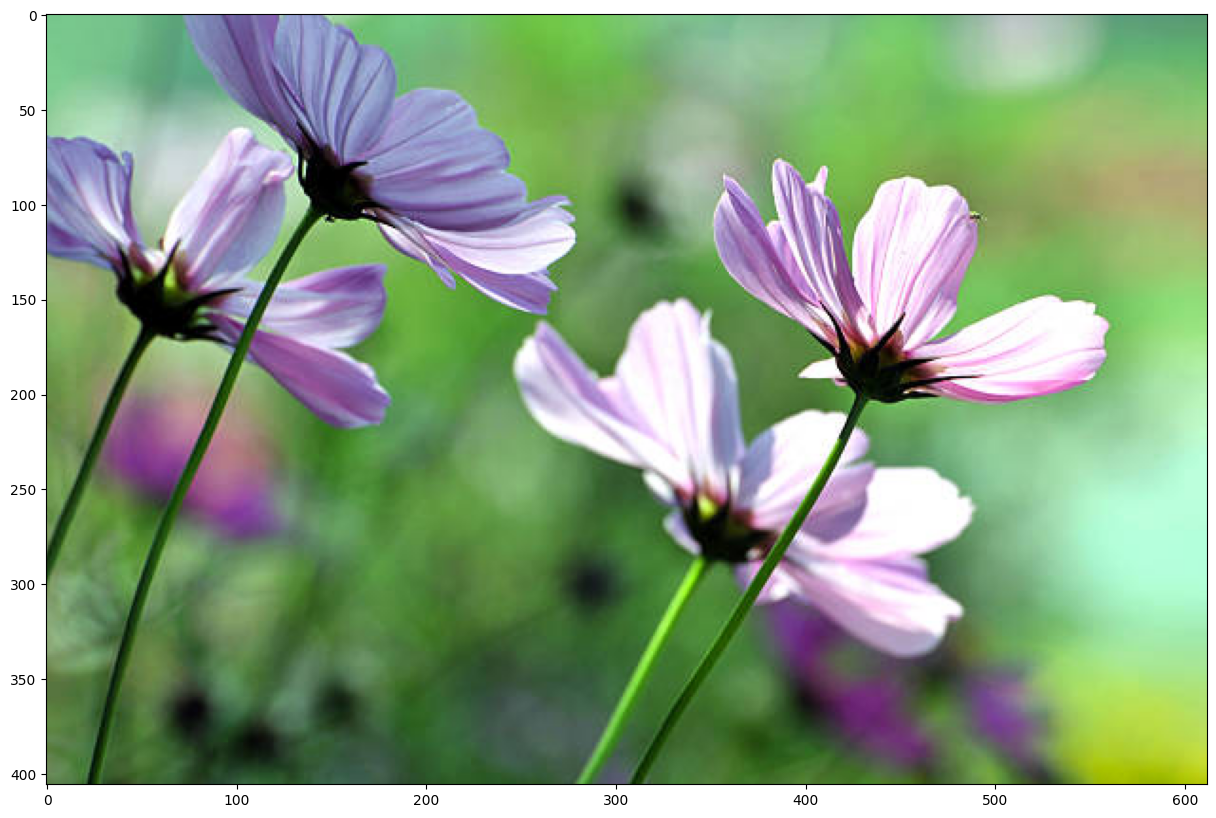

In [20]:
img = cv2.imread('data/flowers.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

(<Axes: >, <matplotlib.image.AxesImage object at 0x7fb7a796ce10>)

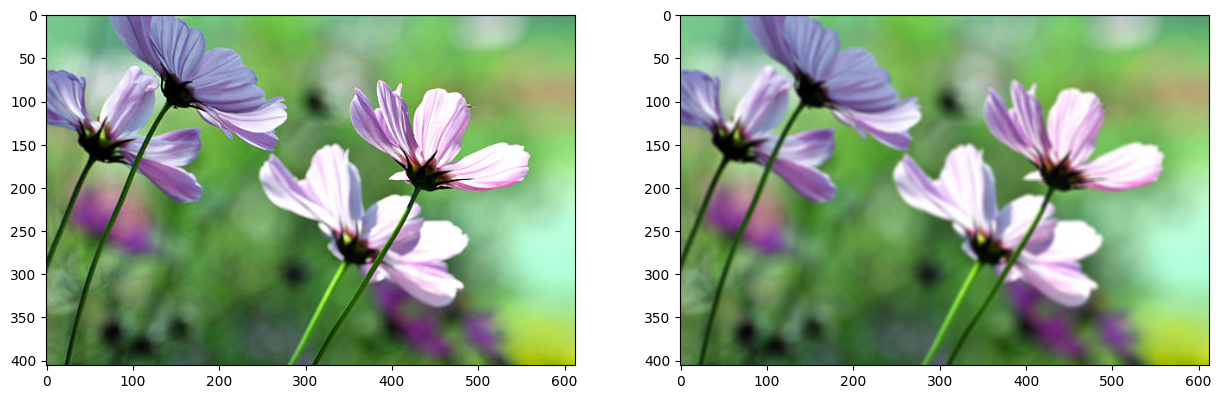

In [69]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
unsharp = cv2.GaussianBlur(img, (5,5), 5)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(unsharp)

In [71]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
diff = img.astype(np.float32) - unsharp.astype(np.float32)

(<Axes: >, <matplotlib.image.AxesImage object at 0x7fb7a7b879d0>)

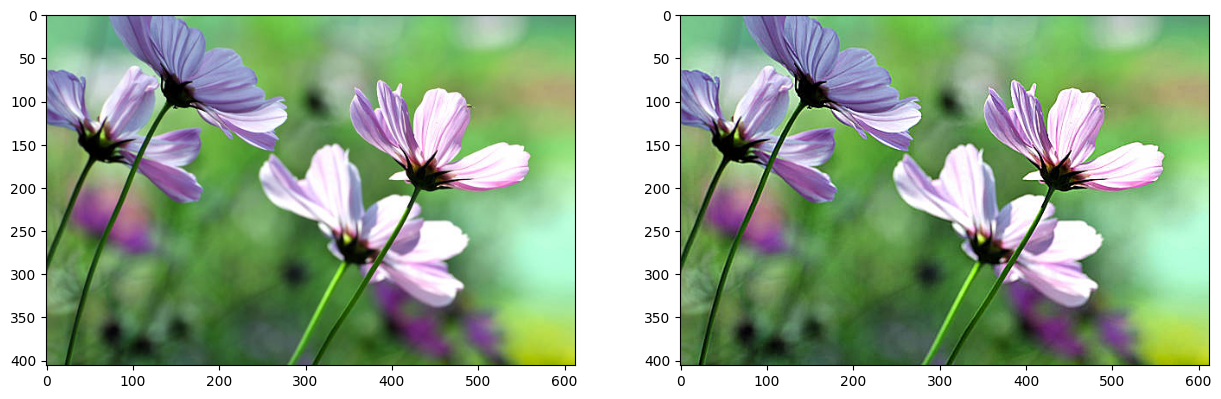

In [72]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.
sharpened = img.astype(np.float32) + diff * 0.6

sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(sharpened)

### Questions
* What is a good (reasonable) value for the `amount` parameter?

It actually depends on a how much the unsrarpened image is blured (a combo of
convolution matrix size and sigma are a key here). The more the unsharpened
image is blurred, the smaller should be the "amount" param.

Example rules from the Wikipedia article: *"Generally a radius of 0.5 to 2
pixels and an amount of 50–150% is recommended"*, *"Unsharp masking may also be
used with a large radius and a small amount (such as 30–100 pixel radius and
5–20% amount)"*

In my example, with the convolution matrix of `5x5` and `sigma=5`, the reasonable (personal best) `amount` value is `0.6`.

* What happens if it is too small?

Then the applied "difference" becomes trivial, and no sharpening effect can be noticed.

* What happens if it is too large?

The image becomes harsh, innatural, with too much noise in previously blurred (unfocused) parts.

* General recommendations on image filtering

Blurring radius and the `amount` value interact (work together). Higher radius can cause halos at the edges, fine detail needs smaller radius (based on Wikipedia article and tested on practice). The amount controls how much contrast is added at the edges.